In [6]:
import jax
import jax.numpy as jnp

import numpy
from matplotlib import pyplot as plt

from learned_optimization.outer_trainers import full_es
from learned_optimization.outer_trainers import truncated_pes
from learned_optimization.outer_trainers import gradient_learner
from learned_optimization.outer_trainers import truncation_schedule

from learned_optimization.tasks import quadratics
from learned_optimization.tasks.fixed import image_mlp
from learned_optimization.tasks import base as tasks_base
from learned_optimization.tasks.datasets import base as datasets_base

from learned_optimization.learned_optimizers import base as lopt_base
from learned_optimization.learned_optimizers import mlp_lopt
from learned_optimization.optimizers import base as opt_base

from learned_optimization import optimizers
from learned_optimization import eval_training

import haiku as hk
import tqdm

In [9]:
key = jax.random.PRNGKey(0)
task = image_mlp.ImageMLP_FashionMnist8_Relu32()

params = task.init(key)
print(jax.tree_util.tree_structure(params))
print(jax.tree_util.tree_map(lambda x: x.shape, params))

PyTreeDef({'mlp/~/linear_0': {'b': *, 'w': *}, 'mlp/~/linear_1': {'b': *, 'w': *}})
{'mlp/~/linear_0': {'b': (32,), 'w': (64, 32)}, 'mlp/~/linear_1': {'b': (10,), 'w': (32, 10)}}


In [11]:
batch = next(task.datasets.train)
jax.tree_util.tree_map( lambda x: (x.shape, x.dtype), batch)

FlatMap({
  'image': ((128, 8, 8, 1), dtype('float32')),
  'label': ((128,), dtype('int32')),
})

In [12]:
key, key1 = jax.random.split(key)

loss = task.loss(params, key1, batch)
loss

Array(2.3176446, dtype=float32)

In [15]:
loss, grad = jax.value_and_grad(task.loss)(params, key1, batch)
jax.tree_util.tree_map(lambda x: x.shape, grad)

{'mlp/~/linear_0': {'b': (32,), 'w': (64, 32)},
 'mlp/~/linear_1': {'b': (10,), 'w': (32, 10)}}

In [24]:
grad_fn = jax.jit(jax.value_and_grad(task.loss))
key = jax.random.PRNGKey(0)
params = task.init(key)
lr = 0.1

for i in range(1000):
    key, key1 = jax.random.split(key)
    batch = next(task.datasets.train)
    l, grads = grad_fn(params, key1, batch)
    params = jax.tree_util.tree_map(lambda p, g: p - lr*g, params, grads)
    if i%100 == 0:
        test_l = task.loss(params, key, next(task.datasets.test))
        print(f"train loss at {i}: {float(l)}. Test loss: {float(test_l)}")

train loss at 0: 2.2845046520233154. Test loss: 2.320131301879883
train loss at 100: 1.3356246948242188. Test loss: 1.3875573873519897
train loss at 200: 1.0104143619537354. Test loss: 1.0793914794921875
train loss at 300: 0.8467453122138977. Test loss: 0.9300081729888916
train loss at 400: 0.8599814176559448. Test loss: 0.764909029006958
train loss at 500: 0.824335515499115. Test loss: 0.7294652462005615
train loss at 600: 0.8042398691177368. Test loss: 0.7608433961868286
train loss at 700: 0.7359169721603394. Test loss: 0.7270013093948364
train loss at 800: 0.6631714105606079. Test loss: 0.5303723812103271
train loss at 900: 0.7689268589019775. Test loss: 0.7120078802108765


In [25]:
fake_params = {"a": jnp.zeros((2,))}

opt = opt_base.SGD(1e-4)
opt_state = opt.init(fake_params)
opt_state

OptaxState(params={'a': Array([0., 0.], dtype=float32)}, state=None, optax_opt_state=(EmptyState(), EmptyState()), iteration=0)

In [26]:
fake_grads = {"a": jnp.ones((2,))}
fake_loss = 10.

next_opt_state = opt.update(opt_state, fake_grads, fake_loss)
opt.get_params(next_opt_state)

{'a': Array([-0.0001, -0.0001], dtype=float32)}

In [38]:
task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)
params = task.init(key)
# print(params)
opt = opt_base.Adam(1e-2)
opt_state = opt.init(params, key)
# print(opt_state)
for i in range(10):
    batch = next(task.datasets.train)
    # print(batch)
    key, key1 = jax.random.split(key)
    params = opt.get_params(opt_state)
    loss, grads = jax.value_and_grad(task.loss)(params, key1, batch)
    opt_state = opt.update(opt_state, grads, loss)
    print(loss)

2.3364477
2.2367635
2.1612422
2.1102824
2.0390062
1.9848582
1.8971167
1.8681295
1.7350136
1.7056153


In [ ]:
task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)
params = task.init(key)

opt = opt_base.Adam(1e-2)
opt_state = opt.init(params)

@jax.jit
def update(opt_state, key, batch):
    key, key1 = jax.random.split(key)
    bb = next(task.datasets.train)
    params, model_state = opt.get_params_state(opt_state)
    print(model_state)
    loss, grads = jax.value_and_grad(task.loss)(params, key, batch)
    print(opt_state)
    opt_state = opt.update(opt_state, grads, loss=loss)
    print(opt_state)
    return opt_state, key, loss

for i in range(10):
    batch = next(task.datasets.train)
    opt_state, key, loss = update(opt_state, key, batch)
    print(loss)

FlatMap({
  'image': JitTracer<float32[128,8,8,1]>,
  'label': JitTracer<int32[128]>,
})
FlatMap({
  'image': array([[[[0.00000000e+00],
                    [0.00000000e+00],
                    [1.10049017e-01],
                    ...,
                    [7.45098069e-02],
                    [0.00000000e+00],
                    [0.00000000e+00]],
           
                   [[0.00000000e+00],
                    [0.00000000e+00],
                    [6.79411769e-01],
                    ...,
                    [7.93627441e-01],
                    [2.45098054e-04],
                    [0.00000000e+00]],
           
                   [[0.00000000e+00],
                    [4.49264705e-01],
                    [8.00735295e-01],
                    ...,
                    [8.79901946e-01],
                    [3.08823526e-01],
                    [0.00000000e+00]],
           
                   ...,
           
                   [[0.00000000e+00],
                    [6.816176

In [65]:
# Defining custom optimizer

import flax
from typing import Any

@flax.struct.dataclass
class MomentumOptState:
    params: Any
    model_state: Any
    iteration: jnp.ndarray
    momentums: Any

class MomentumOptimizer(opt_base.Optimizer):
    
    def __init__(self, lr=1e-3, momentum=0.9):
        super().__init__()
        self._lr = lr
        self._momentum = momentum
        
    def get_state(self, opt_state):
        return opt_state.model_state
    
    def get_params(self, opt_state):
        return opt_state.params
    
    def init(self, params, model_state=None, **kwargs):
        return MomentumOptState(
            params=params,
            model_state=model_state,
            momentums=jax.tree_util.tree_map(jnp.zeros_like, params),
            iteration=jnp.asarray(0, dtype=jnp.int32)
        )
        

    def update(self, opt_state, grads, model_state):
        def update_fn(momentum, grad, param):
            next_m = momentum * self._momentum + grad * (1 - self._momentum)
            next_p = param - next_m * self._lr
            return next_p, next_m

        # Use tree_map to apply update_fn to each leaf in the tree structure
        x = jax.tree_util.tree_map(
            lambda momentum, grad, param: update_fn(momentum, grad, param),
            opt_state.momentums, grads, opt_state.params
        )
        print(x)
        output_params, output_momentums = x
        print(output_momentums)
        print(output_params)
        # Return the updated opt_state with the new params and momentums
        return MomentumOptState(
            params=output_params,
            model_state=model_state,
            iteration=opt_state.iteration + 1,
            momentums=output_momentums
        )

        
opt = MomentumOptimizer(lr=1)
opt_state = opt.init({"a": 1.0, "b": 2.0})
opt.update(opt_state, {"a": -1.0, "b": 1.0}, 1.0)

{'a': (Array(1.1, dtype=float32, weak_type=True), Array(-0.1, dtype=float32, weak_type=True)), 'b': (Array(1.9, dtype=float32, weak_type=True), Array(0.1, dtype=float32, weak_type=True))}
b
a


MomentumOptState(params='a', model_state=1.0, iteration=Array(1, dtype=int32), momentums='b')

In [45]:
lopt = lopt_base.LearnableAdam()
theta = lopt.init(key)
theta

opt = lopt.opt_fn(theta)
opt_state = opt.init({"p": jnp.zeros([2,])})


In [47]:
task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)

lopt = lopt_base.LearnableAdam()

def meta_loss(theta, key, batch):
    opt = lopt.opt_fn(theta)
    key1, key = jax.random.split(key)
    param = task.init(key1)
    opt_state = opt.init(param)
    for i in range(4):
        param = opt.get_params(opt_state)
        key1, key = jax.random.split(key)
        l, grad = jax.value_and_grad(task.loss)(param, key1, batch)
        opt_state = opt.update(opt_state, grad, l)
    param, state = opt.get_params_state(opt_state)
    key1, key = jax.random.split(key)
    final_loss = task.loss(param, key1, batch)
    return final_loss

batch = next(task.datasets.train)
meta_loss(theta, key, batch)

Array(2.2672672, dtype=float32)

In [48]:
meta_value_and_grad = jax.jit(jax.value_and_grad(meta_loss))

ml, meta_grad = meta_value_and_grad(theta, key, batch)
meta_grad

{'log_epsilon': Array(7.813052e-08, dtype=float32, weak_type=True),
 'log_lr': Array(-0.05490893, dtype=float32, weak_type=True),
 'one_minus_beta1': Array(9.462236e-06, dtype=float32),
 'one_minus_beta2': Array(-3.056526e-07, dtype=float32)}

In [49]:
theta_opt = opt_base.Adam(1e-2)

key = jax.random.PRNGKey(0)
theta = lopt.init(key)
theta_opt_state = theta_opt.init(theta)

learning_rates = []
learnable_adam_meta_losses = []
for i in range(2000):
    batch = next(task.datasets.train)
    key, key1 = jax.random.split(key)
    theta = theta_opt.get_params(theta_opt_state)
    ml, meta_grad = meta_value_and_grad(theta, key, batch)
    theta_opt_state = theta_opt.update(theta_opt_state, meta_grad, ml)
    learning_rates.append(theta["log_lr"])
    learnable_adam_meta_losses.append(ml)
    if i % 100 == 0:
        print(ml)

2.258893
2.1435392
1.6287003
1.124637
1.151026
1.2013901
1.1442099
1.2689922
1.3036683
1.1609715
1.5189989
1.1434304
1.3100195
1.04907
1.1879709
1.2017269
1.1939284
1.2104828
1.108221
1.2565413


Text(0.5, 0, 'meta-iteration')

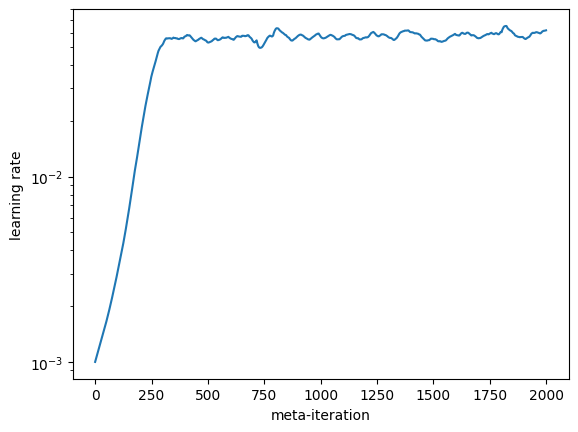

In [51]:
import numpy as np
from matplotlib import pyplot as pyplot

plt.semilogy(np.exp(learning_rates))
plt.ylabel("learning rate")
plt.xlabel("meta-iteration")

9.494337
9.292413
8.27243
7.6280437
7.714888
8.459611
7.8638706
7.5128984
7.79689
7.853068
7.478837
7.342464
6.953003
7.533696
7.4443474
7.9679465
7.529297
7.4888477
7.808234
7.699374


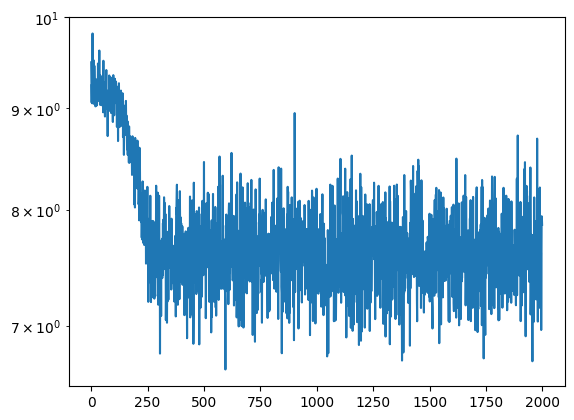

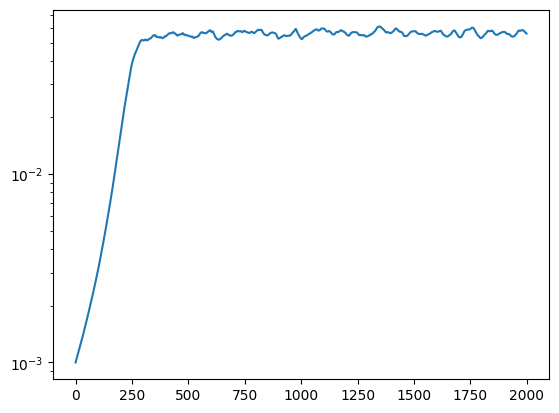

In [121]:

task = image_mlp.ImageMLP_FashionMnist8_Relu32()
key = jax.random.PRNGKey(0)

lopt = lopt_base.LearnableAdam()

# we want to train this theta using meta_loss, how theta optimizer performs on the task.
@jax.jit
def meta_loss_fn(theta, key, batch, meta_loss):
    opt = lopt.opt_fn(theta)
    key, key1 = jax.random.split(key)
    params = task.init(key1)
    opt_state = opt.init(params)
    for i in range(4):
        params = opt.get_params(opt_state)
        key, key1 = jax.random.split(key)
        l, grads = jax.value_and_grad(task.loss)(opt_state.params, key1, batch)
        # l, grads = jax.value_and_grad(task.loss)(params, key1, batch)
        meta_loss += l
        opt_state = opt.update(opt_state, grads, l)
    params, state = opt.get_params_state(opt_state)
    key1, key = jax.random.split(key)
    final_loss = task.loss(params, key1, batch)
    # final_loss = task.loss(opt_state.params, key1, batch)
    return meta_loss

theta_opt = opt_base.Adam(1e-2)

key, key1 = jax.random.split(key)
theta = lopt.init(key1)
theta_opt_state = theta_opt.init(theta)

meta_losses = []
learning_rates = []
meta_value_and_grad = jax.jit(jax.value_and_grad(meta_loss_fn))

for i in range(2000):
    batch = next(task.datasets.train)
    key, key1 = jax.random.split(key)
    theta = theta_opt.get_params(theta_opt_state)
    meta_loss = jnp.asarray(0, dtype=jnp.int32)
    # ml, meta_grads = meta_value_and_grad(theta, key1, batch, meta_loss)
    ml, meta_grads = meta_value_and_grad(theta_opt_state.params, key1, batch, meta_loss)
    theta_opt_state = theta_opt.update(theta_opt_state, meta_grads, ml)
    meta_losses.append(ml)
    learning_rates.append(theta["log_lr"])
    if i % 100 == 0:
        print(ml)

plt.semilogy(meta_losses)
plt.show()
plt.semilogy(np.exp(learning_rates))
plt.show()

In [ ]:
import numpy as np
import jax.numpy as jnp
import jax
from matplotlib import pylab as plt

from learned_optimization.tasks import base as tasks_base
from learned_optimization.learned_optimizers import base as lopt_base
from learned_optimization.optimizers import base as opt_base
from learned_optimization.tasks.datasets import base as datasets_base

from learned_optimization.outer_trainers import full_es
from learned_optimization.outer_trainers import truncated_pes
from learned_optimization.outer_trainers import gradient_learner
from learned_optimization.outer_trainers import truncation_schedule

from learned_optimization.tasks import quadratics
from learned_optimization.tasks.fixed import image_mlp

from learned_optimization.learned_optimizers import mlp_lopt

from learned_optimization import optimizers
from learned_optimization import eval_training

import haiku as hk
import tqdm


In [123]:
import numpy as np

def data_iterator():
    bs = 3
    while True:
        batch = {"data": np.zeros([bs, 5])}
        yield batch
        
@datasets_base.dataset_lru_cache
def get_datasets():
    return datasets_base.Datasets(
        train = data_iterator(),
        inner_valid=data_iterator(),
        outer_valid=data_iterator(),
        test=data_iterator()
    )
    
ds = get_datasets()
next(ds.train)

{'data': array([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])}

In [125]:
def noise_datasets():
    
    def _fn():
        while True:
            yield np.random.normal(size=[4, 2]).astype(dtype=np.float32)
    
    return datasets_base.Datasets(
        train=_fn(),
        inner_valid=_fn(),
        outer_valid=_fn(),
        test=_fn()
    )

class MyTask(tasks_base.Task):
    datasets = noise_datasets()
    
    def loss(self, params, rng, data):
        return jnp.sum(jnp.square(params-data))

    def init(self, key):
        return jax.random.normal(key, shape=[4, 2])
    
task = MyTask()
key = jax.random.PRNGKey(0)
key1, key = jax.random.split(key)
params = task.init(key)

task.loss(params, key1, next(task.datasets.train))

Array(7.1312933, dtype=float32)

In [ ]:
import datasets

data = datasets.load_dataset("allenai/c4", "en", split="train", streaming=True)
seed_for_shuffle = 42 
data: datasets.Dataset = data.shuffle(seed=seed_for_shuffle)



In [ ]:
@torch.no_grad()
def evaluate_model(model, preprocess_batched, pad_idx, global_rank, world_size, device, batch_size):
    val_data = datasets.load_dataset("c4", "en", split="validation", streaming=True)
    val_data = val_data.shuffle(seed=42)
    val_data_mapped = val_data.map(
        preprocess_batched,
        batched=True,
        remove_columns=["text", "timestamp", "url"],
    )
    def batch_fn(dataset, batch_size):
        batch = []
        for example in dataset:
            batch.append(example)
            if len(batch) == batch_size:
                batch = collate_fn(batch)
                yield batch
                batch = []
        if len(batch) > 0:
            yield batch
    # lambda function, which returns dataiterator of particular batch size
    val_data_mapped.batch = lambda batch_size: training_utils.batch_fn(val_data_mapped, batch_size)
    
    target_eval_tokens = 10_000_000
    evaluated_on_tokens = 0
    total_loss = torch.tensor(0.0).to(device)
    total_batches = 1
    logger.info(f"Eval set prepared in {time.time() - _time:.2f} seconds")

    for batch in val_data_mapped.batch(batch_size=batch_size):
        if evaluated_on_tokens > target_eval_tokens:
            break
        total_batches += 1

        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["input_ids"].clone()
        labels[labels == pad_idx] = -100
        loss = model(**batch, labels=labels).loss
        total_loss += loss.detach()

        evaluated_on_tokens += (batch["input_ids"] != pad_idx).sum().item()

    total_loss = total_loss / total_batches
return total_loss, evaluated_on_tokens

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("t5-base", model_max_length=args.max_length)

def preprocess_batched(batch):
    batch = tokenizer(
        batch["text"],
        max_length=args.max_length,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    return batch

dataset = PreprocessedIterableDataset(data, tokenizer, batch_size=args.batch_size, max_length=args.max_length)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=None, num_workers=args.workers)

model_config = AutoConfig.from_pretrained(args.model_config)


model: JAX_LlamaForCausalLM = AutoModelForCausalLM.from_config(model_config)

# first version of code assumes we are no galore optimizer, just simple training.

# should we use adam8bit optimizer?
optimizer = torch.optim.Adam(trainable_params, lr=args.lr, weight_decay=args.weight_decay)

# the scheduler is need in some cases only, adam requires
scheduler = training_utils.get_scheculer(
    optimizer=optimizer,
    scheduler_type=args.scheduler,
    num_training_steps=args.num_training_steps,
    warmup_steps=args.warmup_steps,
    min_lr_ratio=args.min_lr_ratio,
)

pad_idx = tokenizer.pad_token_id

# move the model to gpu and changed dtype, correpsonding in python is model.to(device=device, dtype=torch.bfloat16)

for batch_idx, batch in enumerate(dataloader):
    batch = {k: v.to(device) for k, v in batch.items()}
    labels = batch["input_ids"].clone()
    labels[labels == pad_idx] = -100
    loss = model(**batch, labels=labels).loss
    loss.backward()
    if args.grad_clipping != 0.0: torch.nn.utils.clip_grad_norm_(trainable_params, args.grad_clipping)
    
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

# evaluation and model saving
total_loss, evaluated_on_tokens = evaluate_model(
    model, preprocess_batched, pad_idx, global_rank, world_size, device, args.batch_size
)
print(total_loss)

try:
    model.module.save_pretrained(current_model_directory)
except:
    model.save_pretrained(current_model_directory)

model.eval()
del loss, optimizer, scheduler



NameError: name 'AutoTokenizer' is not defined

In [127]:
import jax
import optax
import flax
import jax.numpy as jnp
import math

from flax.training import train_state
from flax.training.common_utils import get_metrics, onehot, shard

import numpy as np
from tqdm.notebook import tqdm


JAX/FLAX tutorial HF

In [ ]:
# figure these out from the arguments used in OSD repo, note galore doesn't use epochs, they use total num steps
per_device_batch_size = 16
num_epochs = 10
training_seed = 0
learning_rate = 3e-4

total_batch_size = per_device_batch_size * jax.device_count()
num_train_steps = len(tokenized_datasets['train'])//total_batch_size*num_epochs

In [ ]:
from transformers import FlaxAutoModelForCausalLM
from transformers import AutoConfig

config = AutoConfig.from_pretrained("/Users/subhashp/Personal/learning-to-optimize/Online-Subspace-Descent/configs/llama_9m.json")
model = FlaxAutoModelForCausalLM.from_config(config, seed=training_seed, dtype=jnp.dtype("bfloat16"))

FileNotFoundError: [Errno 2] No such file or directory